In [1]:
# 1. Import necessary libraries
# -----------------------------
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import pickle

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# 2. Load the Iris dataset
# ------------------------
# The Iris dataset is a classic and is included with scikit-learn.
# It contains 150 samples of iris flowers, with four features and three species.
iris = load_iris()
X = iris.data  # Features (Sepal Length, Sepal Width, Petal Length, Petal Width)
y = iris.target  # Target labels (species: 0, 1, 2)

# Create a DataFrame for better data handling and visualization
df = pd.DataFrame(data=X, columns=iris.feature_names)
df['species'] = y
print("\nDataset loaded. First 5 rows of the dataframe:")
print(df.head())
print("\nShape of the features (X):", X.shape)
print("Shape of the target (y):", y.shape)


Dataset loaded. First 5 rows of the dataframe:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  

Shape of the features (X): (150, 4)
Shape of the target (y): (150,)


In [3]:
# 3
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("\nData split into training and testing sets.")
print(f"Training data size: {X_train.shape[0]} samples")
print(f"Testing data size: {X_test.shape[0]} samples")



Data split into training and testing sets.
Training data size: 105 samples
Testing data size: 45 samples


In [4]:
# 4. Model Training
model = KNeighborsClassifier(n_neighbors=3)
print("\nModel (K-Nearest Neighbors) initialized.")

# Train the model using the training data
model.fit(X_train, y_train)
print("Model trained successfully.")


Model (K-Nearest Neighbors) initialized.
Model trained successfully.


In [16]:
# 5. Make Predictions

y_pred = model.predict(X_test)
print("\nPredictions made on the test data.")
print("Sample predictions vs actual values:")
for i in range(5):
    print(f"  Predicted: {iris.target_names[y_pred[i]]}, Actual: {iris.target_names[y_test[i]]}")

accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy Score: {accuracy:.2f}")


Predictions made on the test data.
Sample predictions vs actual values:
  Predicted: virginica, Actual: virginica
  Predicted: versicolor, Actual: versicolor
  Predicted: versicolor, Actual: virginica
  Predicted: versicolor, Actual: versicolor
  Predicted: virginica, Actual: virginica

Accuracy Score: 0.96


In [6]:
# 6. Evaluate the Model's Performance

accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy Score: {accuracy:.2f}")

# b. 
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# c. 
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)



Accuracy Score: 0.96

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.88      1.00      0.94        15
   virginica       1.00      0.87      0.93        15

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45


Confusion Matrix:
[[15  0  0]
 [ 0 15  0]
 [ 0  2 13]]


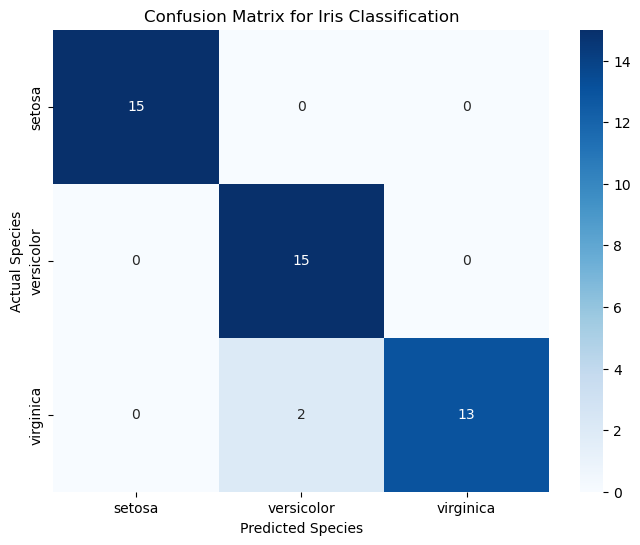


Script execution finished. A plot of the confusion matrix has been displayed.


In [7]:
# 7. Visualize the Confusion Matrix

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title('Confusion Matrix for Iris Classification')
plt.xlabel('Predicted Species')
plt.ylabel('Actual Species')
plt.show()
print("\nScript execution finished. A plot of the confusion matrix has been displayed.")


In [8]:
# 8. Save the Trained Model

model_joblib_filename = 'iris_knn_model.joblib'
joblib.dump(model, model_joblib_filename)
print(f"\nModel successfully saved as '{model_joblib_filename}' using joblib.")

# Save the model using pickle
model_pickle_filename = 'iris_knn_model.pkl'
with open(model_pickle_filename, 'wb') as file:
    pickle.dump(model, file)
print(f"Model successfully saved as '{model_pickle_filename}' using pickle.")

print("\nModel saving complete.")


Model successfully saved as 'iris_knn_model.joblib' using joblib.
Model successfully saved as 'iris_knn_model.pkl' using pickle.

Model saving complete.
